In [6]:
import numpy as np
import cv2
import os
import pandas as pd
from PIL import Image
import h5py
import matplotlib.pyplot as plt
from scipy import io
from time import time
print(os.getcwd())

/Users/matte/Library/CloudStorage/GoogleDrive-matteobonotto90@gmail.com/Other computers/Dell Eni/Prove/PyTorch-Lightning-template/notebooks


In [7]:
paths_load = [
    r'../data/fashion-mnist/fashion-mnist_train.csv',
    r'../data/fashion-mnist/fashion-mnist_test.csv'
    ]

n_scale = 4

paths_save = [
    '../data/fashion-mnist/fashion-mnist_{}x{}_train'.format(n_scale*28,n_scale*28),
    '../data/fashion-mnist/fashion-mnist_{}x{}_test'.format(n_scale*28,n_scale*28),
    ]

for fileload, filesave in zip(paths_load, paths_save):
    print('Processing {}'.format(filesave))
    data = pd.read_csv(fileload, low_memory=False).to_numpy()
    X,y = data[:,1:], data[:,0]
    dims = X.shape
    dims = [int(x) for x in [dims[0], np.sqrt(dims[1]), np.sqrt(dims[1])]]
    X = X.reshape(dims)

    X_resize = np.zeros((
        X.shape[0],
        n_scale*X.shape[1],
        n_scale*X.shape[2]))
    
    for i in range(X.shape[0]):
        if i/10000 == i//10000:
            print('   -> Step {} of {}'.format(i,X.shape[0]))
        x = X[i,...]
        im = Image.fromarray(np.uint8(x)).convert('L').resize(
            (n_scale*x.shape[0],n_scale*x.shape[1]), Image.Resampling.LANCZOS
        )
        X_resize[i,...] = np.asarray(im)
    X = X_resize

    print('   Saving ...')
    
    #TODO 
    
    mdict = {'X':X}
    t_start = time()
    io.savemat(filesave + '.mat',mdict)
    print(time() - t_start)
    
    t_start = time()
    compression = "gzip" #lzf
    with h5py.File(filesave + '.h5', 'w') as hf:
        hf.create_dataset('X', data=X, compression=compression,shape=X.shape)
        # hf.create_dataset('y', data=y, compression=compression,shape=y.shape)
    hf.close()
    print(time() - t_start)

    print('   Done saving!')

print('Done!')

Processing ../data/fashion-mnist/fashion-mnist_112x112_train


   -> Step 0 of 60000
   -> Step 10000 of 60000
   -> Step 20000 of 60000
   -> Step 30000 of 60000
   -> Step 40000 of 60000
   -> Step 50000 of 60000


KeyboardInterrupt: 

In [6]:
n_scale = 6
paths_save = [
    '../data/fashion-mnist/fashion-mnist_{}x{}_train'.format(n_scale*28,n_scale*28),
    '../data/fashion-mnist/fashion-mnist_{}x{}_test'.format(n_scale*28,n_scale*28),
    ]

with h5py.File(paths_save[0] + '.h5', 'r') as hf:
    a=0
    X,y  = hf['X'][()], hf['y'][()]
    # X = np.zeros(X.shape)
    # hf['X'].read_direct(X)


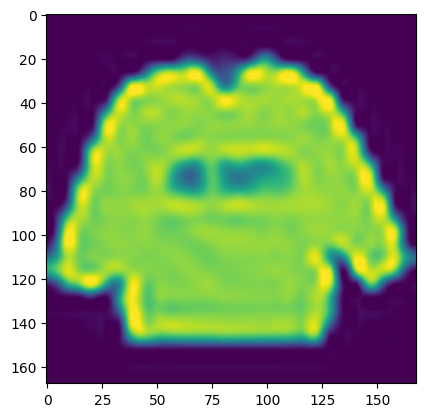

In [5]:
plt.imshow(X[0,:,:])
plt.show()